In [1]:
!pip install ~/fwiVis/utility_functions/
! pip install plotnine


Processing /home/jovyan/fwiVis/utility_functions
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for fwiVis: filename=fwivis-0.1-py3-none-any.whl size=5594 sha256=66fce5f229c09ed82ef556d21a1c95d277f81d85f82f1f31cfdaa5d608281122
  Stored in directory: /tmp/pip-ephem-wheel-cache-1j24l67o/wheels/79/0f/3d/08c18473dd7e0fb915900e6b4f13b81f1fa84371f9bf24d864
Successfully built fwiVis
  Attempting uninstall: fwiVis
    Found existing installation: fwiVis 0.1
    Uninstalling fwiVis-0.1:
      Successfully uninstalled fwiVis-0.1


In [2]:
import s3fs
s3 = s3fs.S3FileSystem(anon=False)
from math import cos, asin, sqrt
import re

import numpy as np
import geopandas as gpd
import pandas as pd
from matplotlib import pyplot as plt
import os
import rioxarray as rio
import xarray as xr
import rasterio
import glob
from shapely.errors import ShapelyDeprecationWarning
from shapely.geometry import Point
import warnings
import folium
import datetime
import time
from folium import plugins
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
#import contextily as cx
from shapely.geometry import box
import sys
from datetime import datetime, timedelta
from itertools import chain

from datetime import date
from bs4 import BeautifulSoup
import requests
import os
import plotnine
import xarray as xr
import shapely
import shapely.geometry as gmt
from shapely.geometry import MultiPolygon, Point, Polygon
#import numpy as np
from matplotlib import pyplot as plt
from plotnine import ggplot, geom_point, geom_jitter, aes, stat_smooth, facet_wrap
import plotnine as plotnine
import seaborn as sns


In [3]:
import fwiVis.fwiVis as fv

path = os.path.abspath("data/Quebec_v3_full_data_perimeters20241112.csv")
fire3 = fv.prep_fire_files(path)
fire3 = fire3.sort_values(by = ["fireID", "t"])
fire3 = fire3[~fire3.FWI.isna()]
fire_first = fire3

ciffc = pd.read_csv(os.path.abspath("contextual_data/CIFFC_data/ciffc_all_canada.csv"))
ciffc = ciffc[ciffc.field_agency_code == "qc"]
ciffc = gpd.GeoDataFrame(ciffc, geometry= gpd.points_from_xy(ciffc.field_longitude, ciffc.field_latitude), crs = "4326")
ciffc = ciffc.to_crs("3571")
ciffc["geometry_point"] = ciffc.geometry

pre_data_transform =fire_first.sjoin(ciffc)


In [4]:

def corrected_farea_diff(df, var = "farea"):
    df[f"{var}_diff"] = df[var].diff()
    min_t = df.t.min()
    if(np.isnan(*df.loc[df.t == min_t, [f"{var}_diff"]].values)):
        df.loc[df.t == min_t, [f"{var}_diff"]] = df.loc[df.t == min_t, [f"{var}"]].values
    else:
        print("Error! First value not NaN")
        df = None
    return(df)

def just_the_igs(df,): ## Reminder that this will only acocunt for the earliest ignition from a multi-fire complex. 

    df["is_ig"] = False
    df.loc[df.t == df.t.min(), ['is_ig']] = True
    
    return(df)

def extinction(df, days_past = 1):
    df.loc[:, ['is_ext']] = False
    df.loc[:, ["t"]] = df.t.astype("datetime64[ns]")
    final_t = df[df.n_newpixels > 0].t.astype("datetime64[ns]").max()
    post_fire = final_t + timedelta(days = days_past)

    if (pd.isnull(np.datetime64(str(final_t)))):
        df.loc[(df.t == df.t.min()), ['is_ext']] = True
    else:
        df.loc[(df.t  > final_t)  & (df.t  <= post_fire), ['is_ext']] = True
    return(df)


fire3 = fire3[~fire3.FWI.isna()]

post_fr = fire3

post_fr = post_fr.groupby("fireID").apply(extinction).reset_index(drop = True)
post_fr = post_fr.groupby("fireID").apply(just_the_igs).reset_index(drop = True)

fire3 = fire3.groupby("fireID").apply(corrected_farea_diff).reset_index(drop = True)
fire3 = fire3.groupby("fireID").apply(just_the_igs).reset_index(drop = True)
fire3["frac_change"] = fire3.groupby("fireID").farea.pct_change()
fire3 = fire3.sjoin(ciffc)
fire3["farea_diff"] = fire3.groupby("fireID").farea.diff()
row_mask = (~fire3.fireID.str.contains("_"))

/tmp/ipykernel_4142/2239961976.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_4142/2239961976.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_4142/2239961976.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_grou

In [5]:
supression = fire3.groupby("fireID").field_response_type.unique().reset_index()
supression

supression["len"] = supression.field_response_type.apply(len)

multi_suppress_ids = supression[supression.len> 1].fireID

supression[supression.len> 1]
fire_ids_not_unique_supression = supression[supression.len> 1].fireID

In [6]:
def sep_supression(fid, df1,  meter_crs = 3571, point_crs = 4326): #df2,
    print("Assuming df1 is in  crs 4326, and df2 is in a metered crs (3571)")
    df = df1[df1.fireID == fid]
    ciffc_resp = df.field_response_type.unique()
    resp_l = []
    just_intersect = []
    unique_points = df[["geometry_point", "field_response_type", "field_agency_fire_id"]].drop_duplicates().reset_index(drop = True)
    unique_points = gpd.GeoDataFrame(unique_points, geometry= unique_points.geometry_point,  crs = 3571)
    points = unique_points.geometry_point
    
    for index, row in df.iterrows():
        if(isinstance(row['geometry'], Polygon)):
            row['geometry'] = gmt.MultiPolygon([row['geometry']])
        for polygon in row['geometry'].geoms:
            unique_points["Does_it_intersect"] = np.nan
            intersecting_points = []
            for point in points:
                intersecting_points.append(polygon.intersects(point))
                    
            unique_points["Does_it_intersect"] = intersecting_points
            up_group = unique_points.groupby("field_response_type").Does_it_intersect.unique().reset_index()
            only_one_type_of_supression_intersects = (sum(up_group.Does_it_intersect.explode().values) == 1)
            if only_one_type_of_supression_intersects: ### Only one catagory intersects with this polygon
                new_row = row.copy()
                new_row["geometry"] = polygon
                new_row["farea"] = (polygon.area / (1000 * 1000))
                new_row["fperim"] = np.nan
                new_row["meanFRP"] = np.nan
                sup = str(up_group[up_group.Does_it_intersect.apply(any)].field_response_type.iloc[0])
                new_row["fireID"] = str(fid) + "." + sup +"." +  ".".join(unique_points[unique_points.Does_it_intersect == True].field_agency_fire_id.astype("str"))
                new_row["field_response_type"] = sup
                just_intersect.append(new_row)
            else:
                new_row = row.copy()
                new_row["geometry"] = polygon
    just_intersect_df = gpd.GeoDataFrame(just_intersect)
    just_intersect_df = gpd.GeoDataFrame(just_intersect_df, geometry = just_intersect_df.geometry, crs = 3571)
    just_intersect_df = just_intersect_df.drop_duplicates()
    return(just_intersect_df)
    
def check_that_continious_record(df):
    min_t = df.t.min()
    max_t = df.t.max()
    dates = pd.date_range(start= min_t, end=  max_t).strftime('%Y-%m-%d 12:00:00').tolist()
    len_df = len(df.t.unique())
    len_seq = len(dates)
    if(len_df != len_seq):
        print(f"FireID {df.fireID.unique()} is not a continious sequence.")
        return(False)
    d_list = []
    for d in dates:
        some_dates = df[df.t == d]
        d_list.append(len(some_dates) > 0)
    return(any(d_list))

In [7]:
### remake IDs with dual supression status 
skip_list = ["1082", "1324"] # has more than one supression, but seems like the reported point doesn't overlap with an indepandant multipolygon. 

dual_sup =  [item for item in fire_ids_not_unique_supression if item not in skip_list]
dfs = []
for s in dual_sup:
    print(s)
    tmp = sep_supression(str(s), fire3)
    dfs.append(tmp)
foo = pd.concat(dfs)
foo = gpd.GeoDataFrame(foo, geometry = foo.geometry, crs = 3571)
bools = foo.groupby("fireID").apply(check_that_continious_record) #### Check that there is a continious t. This checks that there are no mistakes from subsetting fires. 
print(f"Are all the fires continuous records?: {all(bools)}")

if(all(bools)):
    fire3 = fire3[~fire3.fireID.isin(fire_ids_not_unique_supression)]
    foo = foo.to_crs(fire3.crs)
    fire3 = pd.concat([fire3, foo], ignore_index=True)

1088
Assuming df1 is in  crs 4326, and df2 is in a metered crs (3571)
226
Assuming df1 is in  crs 4326, and df2 is in a metered crs (3571)
2545
Assuming df1 is in  crs 4326, and df2 is in a metered crs (3571)
2647
Assuming df1 is in  crs 4326, and df2 is in a metered crs (3571)
2649
Assuming df1 is in  crs 4326, and df2 is in a metered crs (3571)
Are all the fires continuous records?: True


/tmp/ipykernel_4142/3375137345.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [8]:
def chop_fires_at_end(df):
    final_t = df[df.n_newpixels > 0].t.max()
    df = df[df.t <= final_t]
    return(df)
fire3 = fire3.groupby("fireID").apply(chop_fires_at_end).reset_index(drop = True)


fire3 = fire3.sort_values(by = ["fireID", "t"])
fire3 = fire3[~fire3.FWI.isna()]

/tmp/ipykernel_4142/462691781.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


## Check CIFFC ignitions

In [9]:
cif_fires = ciffc[~ciffc.field_agency_fire_id.isin(pre_data_transform.field_agency_fire_id)]

In [ ]:
cif_fires.field_fire_size.hist() ## There is one large fire i guess FEDS missed
cif_fires = cif_fires[cif_fires.field_fire_size <= 400] ### only the ones we "should" have tracked

ciffc["field_situation_report_date_no_tz"] = ciffc.field_situation_report_date.str.replace(".000Z", "")
ciffc["field_situation_report_date_no_tz"] = ciffc.field_situation_report_date_no_tz.astype("datetime64[ns]")
ciffc["field_situation_report_date_no_tz"] = ciffc.field_situation_report_date_no_tz.dt.strftime("%Y-%m-%d")


def get_percent_over(series, thresh = 400):
    tot = len(series)
    sub_len = len(series[series >= thresh])
    if(sub_len == 0):
        percent_over = 0
    else:
        percent_over = sub_len / tot
    return(percent_over)
        #print(f"Nothing is over {thresh}")
    
    

ciffc_counts=ciffc.groupby("field_situation_report_date_no_tz").field_agency_fire_id.count().reset_index()
ciffc_counts= ciffc_counts.rename( columns = {"field_agency_fire_id": "num_fire_starts"})

ciffc_counts["percent_large"] = ciffc.groupby("field_situation_report_date_no_tz").field_fire_size.apply(get_percent_over).reset_index(drop = True)

# Figure variations

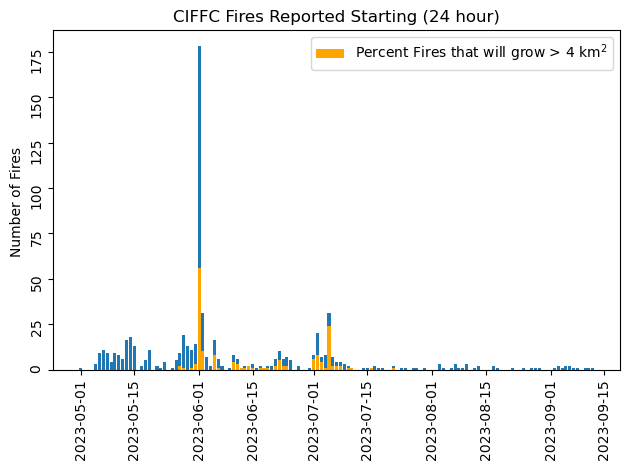

In [11]:
ciffc_counts = ciffc_counts[ciffc_counts.field_situation_report_date_no_tz >= "2023-05-01"]

ciffc_counts = ciffc_counts[ciffc_counts.field_situation_report_date_no_tz <= "2023-09-15"]


plt.bar(ciffc_counts.field_situation_report_date_no_tz.astype("datetime64[ns]"), ciffc_counts.num_fire_starts)
plt.bar(ciffc_counts.field_situation_report_date_no_tz.astype("datetime64[ns]"), ciffc_counts.num_fire_starts * ciffc_counts.percent_large, color = "orange", label = "Percent Fires that will grow > 4 km$^2$")
plt.ylabel("Number of Fires ")
plt.legend()
plt.tick_params(rotation=90)
plt.title("CIFFC Fires Reported Starting (24 hour)")
plt.tight_layout()
plt.savefig(f'{os.path.abspath("exploratory_figs")}/ciffc/ciffc_percent_igs.png')

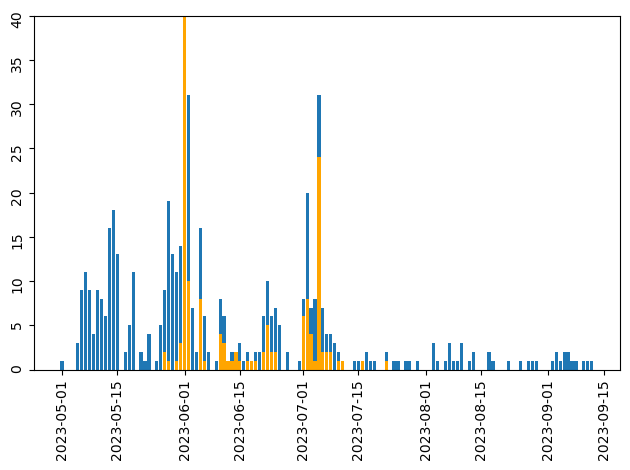

In [12]:
plt.bar(ciffc_counts.field_situation_report_date_no_tz.astype("datetime64[ns]"), ciffc_counts.num_fire_starts)
plt.bar(ciffc_counts.field_situation_report_date_no_tz.astype("datetime64[ns]"), ciffc_counts.num_fire_starts * ciffc_counts.percent_large, color = "orange", label = "Percent Fires that will grow > 4 km$^2$")
plt.ylim((0,40))
#plt.ylabel("Number of Fires ")
#plt.legend()
plt.tick_params(rotation=90)
#plt.title("CIFFC Fires Reported Starting (24 hour)")
plt.tight_layout()
plt.savefig(f'{os.path.abspath("exploratory_figs")}/ciffc_percent_igs_broken_yaxis.png')

In [13]:
#FWI_data_south = pd.read_csv("https://portal.nccs.nasa.gov/datashare/GlobalFWI/ForecastFWIEXPERIMENTAL/QuebecEcoSuppressionRegions/GEOS-5/GEOS-5.IMERGEARLY/90_P/chicletDataNoSmoothing/001.SouthernEcoregions_FullResponseZone.FWI.raw.chiclet.csv")
FWI_data_south = pd.read_csv(f'{os.path.abspath("contextual_data/")}/Local_chiclet_csv/001.SouthernEcoregions_FullResponseZone.FWI.raw.chiclet_MEAN.csv')

#FWI_data_north = pd.read_csv("https://portal.nccs.nasa.gov/datashare/GlobalFWI/ForecastFWIEXPERIMENTAL/QuebecEcoSuppressionRegions/GEOS-5/GEOS-5.IMERGEARLY/90_P/chicletDataNoSmoothing/002.NorthernEcoregions_LimitedResponseZone.FWI.raw.chiclet.csv")

FWI_data_north = pd.read_csv(f'{os.path.abspath("contextual_data/")}/Local_chiclet_csv/002.NorthernEcoregions_LimitedResponseZone.FWI.raw.chiclet_MEAN.csv')


fwis = FWI_data_south[["INITDATE", "0"]]
fwis = fwis.rename(columns={"0":"GEOS_5"})
fwis = fwis.rename(columns={"INITDATE":"t"})
fwis.t = fwis.t.astype("datetime64[ns]")


fwin = FWI_data_north[["INITDATE", "0"]]
fwin = fwin.rename(columns={"0":"GEOS_5"})
fwin = fwin.rename(columns={"INITDATE":"t"})
fwin.t = fwin.t.astype("datetime64[ns]")

In [14]:
ciffc_counts_high =ciffc[ciffc.field_latitude >= 51.5].groupby("field_situation_report_date_no_tz").field_agency_fire_id.count().reset_index()
ciffc_counts_high= ciffc_counts_high.rename( columns = {"field_agency_fire_id": "num_fire_starts"})

ciffc_counts_high["percent_large"] = ciffc[ciffc.field_latitude >= 51.5].groupby("field_situation_report_date_no_tz").field_fire_size.apply(get_percent_over).reset_index(drop = True)


ciffc_counts_high.loc[:, "t"] = ciffc_counts_high["field_situation_report_date_no_tz"].astype("datetime64[ns]")
#ciffc_counts_high["percent_large"] = ciffc_counts_high.groupby("field_situation_report_date_no_tz").field_fire_size.apply(get_percent_over).reset_index(drop = True)

ciffc_counts_high = ciffc_counts_high.merge(fwin)


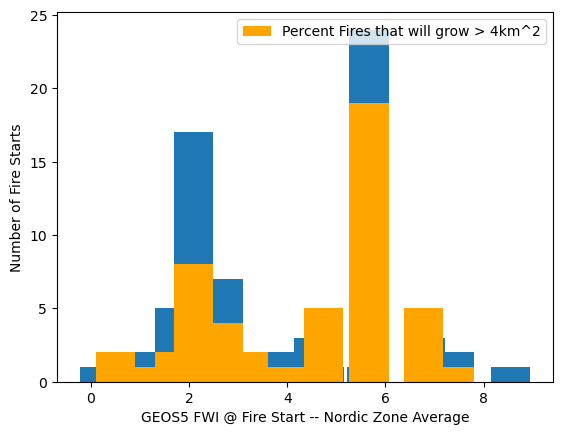

In [15]:
#plt.scatter(ciffc_counts_high.GEOS_5, ciffc_counts_high.num_fire_starts)
plt.bar(ciffc_counts_high.GEOS_5, ciffc_counts_high.num_fire_starts)
plt.bar(ciffc_counts_high.GEOS_5, ciffc_counts_high.num_fire_starts * ciffc_counts_high.percent_large, color = "orange", label = "Percent Fires that will grow > 4km^2")
plt.xlabel("GEOS5 FWI @ Fire Start -- Nordic Zone Average")
plt.ylabel("Number of Fire Starts")
plt.legend()
plt.savefig(f'{os.path.abspath("exploratory_figs")}/ciffc/north_zone_percent_igs.png')

In [16]:
ciffc_counts_low =ciffc[ciffc.field_latitude < 51.5].groupby("field_situation_report_date_no_tz").field_agency_fire_id.count().reset_index()
ciffc_counts_low= ciffc_counts_low.rename( columns = {"field_agency_fire_id": "num_fire_starts"})
ciffc_counts_low["percent_large"] = ciffc[ciffc.field_latitude < 51.5].groupby("field_situation_report_date_no_tz").field_fire_size.apply(get_percent_over).reset_index(drop = True)
ciffc_counts_low.loc[:, "t"] = ciffc_counts_low["field_situation_report_date_no_tz"].astype("datetime64[ns]")
ciffc_counts_low = ciffc_counts_low.merge(fwis)

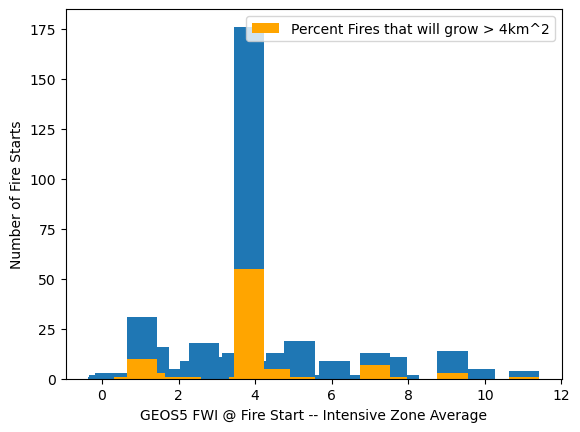

In [17]:
plt.bar(ciffc_counts_low.GEOS_5, ciffc_counts_low.num_fire_starts)
plt.bar(ciffc_counts_low.GEOS_5, ciffc_counts_low.num_fire_starts * ciffc_counts_low.percent_large, color = "orange", label = "Percent Fires that will grow > 4km^2")
plt.xlabel("GEOS5 FWI @ Fire Start -- Intensive Zone Average")
plt.ylabel("Number of Fire Starts")
plt.savefig(f'{os.path.abspath("exploratory_figs")}/ciffc/south_zone_percent_igs.png')
plt.legend()

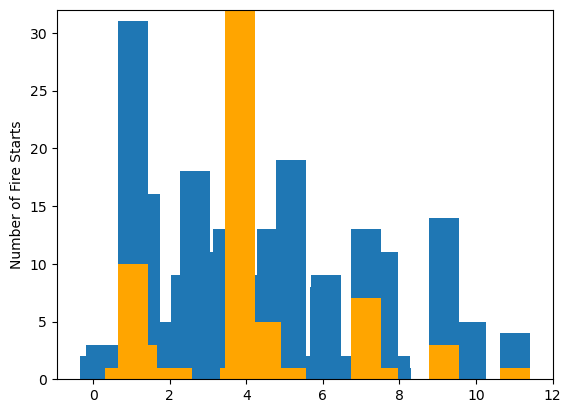

In [18]:
plt.bar(ciffc_counts_low.GEOS_5, ciffc_counts_low.num_fire_starts)
plt.bar(ciffc_counts_low.GEOS_5, ciffc_counts_low.num_fire_starts * ciffc_counts_low.percent_large, color = "orange", label = "Percent Fires that will grow > 4km^2")
plt.ylim((0, 32))
#plt.xlabel("GEOS5 FWI @ Fire Start -- Intensive Zone Average")
plt.ylabel("Number of Fire Starts")
plt.savefig(f'{os.path.abspath("exploratory_figs")}/ciffc/south_brokeny_zone_percent_igs.png')
#plt.legend()

In [19]:
fire_test = fv.formatting_read_in('data/Quebec_v3_full_data_perimeters20241112.csv', start_time = '2023-05-31 00:00:00', end_time = '2023-09-15 12:00:00', gen_cols = True, merge_with_ciffc = False, merge_with_nbac = True)

/srv/conda/envs/notebook/lib/python3.12/site-packages/fwiVis/fwiVis.py:206: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/srv/conda/envs/notebook/lib/python3.12/site-packages/fwiVis/fwiVis.py:235: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/srv/conda/envs/notebook/lib/python3.12/site-packages/fwiVis/fwiVis.py:236: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and

In [20]:
def get_igs(df):
    df.loc[df.t == df.t.min(),  "is_ig"] = True
    return(df)

fire_test = fire_test.groupby("fireID").apply(get_igs)

/tmp/ipykernel_4142/4180013391.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [21]:
fed_igs = pd.DataFrame(columns = ["t", "num_fed_igs"])
for i, t in enumerate(fire_test.t):
    
    fed_igs.loc[i, "t"] = t
    fed_igs.loc[i, "num_fed_igs"] = len(fire_test[(fire_test.t ==t) & (fire_test.is_ig == True)].fireID.unique())


fed_igs.t = fed_igs.t.astype("datetime64[ns]").dt.strftime("%Y-%m-%d")
fed_igs = fed_igs.rename(columns= {"t": "field_situation_report_date_no_tz"})
ciffc_counts= ciffc_counts.merge(fed_igs, on = "field_situation_report_date_no_tz", how = "left" )

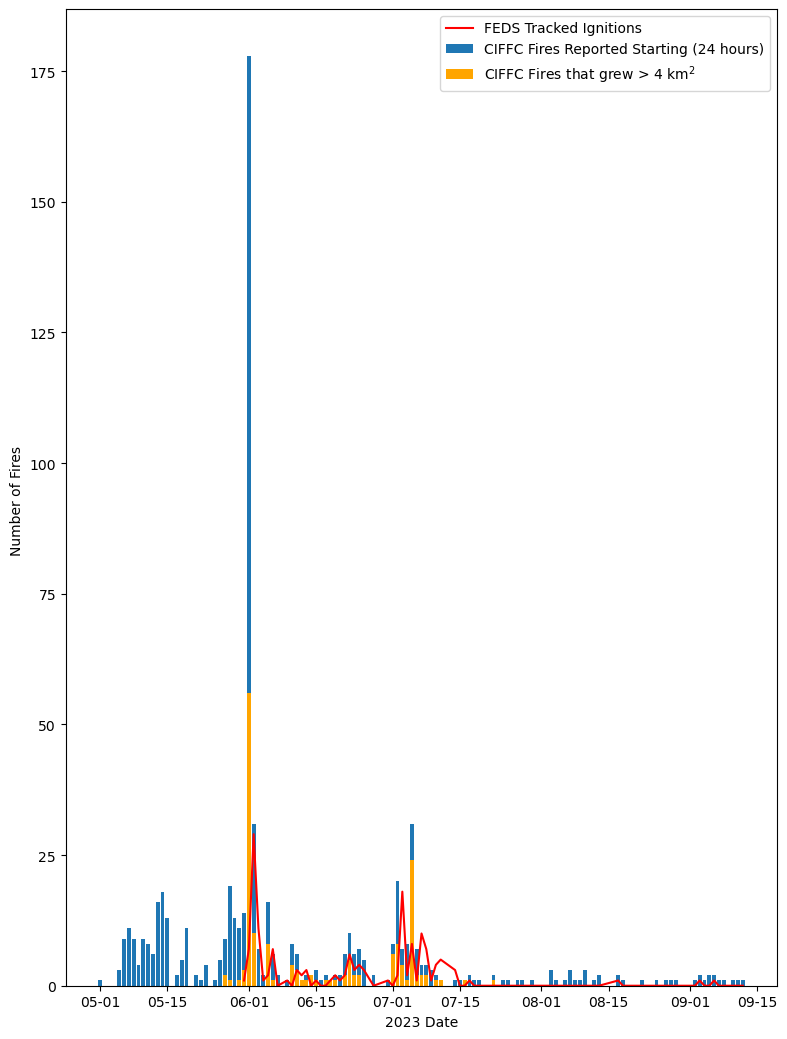

In [22]:
import matplotlib.dates as mdates
import datetime as dt

#plt.rcParams.update({'font.size': 20})

ciffc_counts = ciffc_counts[ciffc_counts.field_situation_report_date_no_tz >= "2023-05-01"]

ciffc_counts = ciffc_counts[ciffc_counts.field_situation_report_date_no_tz <= "2023-09-15"]

date_formatter = mdates.DateFormatter('%m-%d')

fig, ax = plt.subplots(figsize=(8, 10.5))

ax.bar(ciffc_counts.field_situation_report_date_no_tz.astype("datetime64[ns]"), ciffc_counts.num_fire_starts, label = "CIFFC Fires Reported Starting (24 hours)")
ax.bar(ciffc_counts.field_situation_report_date_no_tz.astype("datetime64[ns]"), ciffc_counts.num_fire_starts * ciffc_counts.percent_large, color = "orange", label = "CIFFC Fires that grew > 4 km$^2$")
ax.plot(ciffc_counts.field_situation_report_date_no_tz.astype("datetime64[ns]"), ciffc_counts.num_fed_igs, color = "red", label = "FEDS Tracked Ignitions")
ax.set_ylabel("Number of Fires ")
ax.legend()
ax.xaxis.set_major_formatter(date_formatter)
ax.set_xlabel("2023 Date")
plt.tight_layout()
plt.savefig(f'{os.path.abspath("exploratory_figs")}/ciffc/ciffc_percent_igs_feds.png')

# Look at timing of fire starts

In [23]:
many_fire_igs = ciffc_counts[ciffc_counts.num_fed_igs >= 10]

In [24]:
for t in many_fire_igs.field_situation_report_date_no_tz.unique():
    print(f"at {t}, {many_fire_igs[many_fire_igs.field_situation_report_date_no_tz == t].num_fed_igs.unique()} Fires were igniting")

at 2023-06-02, [29] Fires were igniting
at 2023-06-03, [11] Fires were igniting
at 2023-07-03, [18] Fires were igniting
at 2023-07-07, [10] Fires were igniting


In [25]:
ciffc_counts[(~ciffc_counts.num_fed_igs.isna()) & (ciffc_counts.num_fed_igs >0 )].field_situation_report_date_no_tz.min()

'2023-05-31'

In [26]:
ciffc_counts[(~ciffc_counts.num_fed_igs.isna()) & (ciffc_counts.num_fed_igs >1 )].field_situation_report_date_no_tz.max()

'2023-07-14'